In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

TARGET_INITIAL_THETA = -1.5
TARGET_BETA1 = 0.99
TARGET_BETA2 = 0.999
C_VALUE = 1.5
T_HORIZON = 700
SUBSTEP_FACTOR = 5 
DELTA = 1 

RESULTS_2ND_ORDER_DIR = Path("results_2nd_order")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

In [3]:
# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def f_rosenbrock(theta, c=1.5):
    """
    Rosenbrock 1D function:
    f(theta) = (1 - theta)^2 + c*(theta^2 - 1)^2
    """
    return (1 - theta)**2 + c * (theta**2 - 1)**2

def extract_params_2nd_order(filename):
    """
    Extract parameters from 2nd order filename.
    Expected format: second_order_c_X.X_initial_theta_Y_initial_velocity_Z_lr_W_beta1_V_beta2_U.csv
    """
    match = re.search(
        r'second_order_c_([\d.]+)_initial_theta_([-\d.]+)_initial_velocity_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if match:
        return {
            'c': float(match.group(1)),
            'initial_theta': float(match.group(2)),
            'initial_velocity': float(match.group(3)),
            'lr': float(match.group(4)),
            'beta1': float(match.group(5)),
            'beta2': float(match.group(6))
        }
    return None

def calculate_trajectory_difference(theta_v0, theta_ref, t_array, delta, T):
    """
    Calculate sup-norm difference between two trajectories after initial layer delta.
    
    Args:
        theta_v0: trajectory with initial velocity v0
        theta_ref: reference trajectory
        t_array: time array
        delta: initial layer cutoff
        T: final time
    
    Returns:
        Delta_theta: sup norm of theta difference in [delta, T]
    """
    # Mask for time window [δ, T]
    mask = (t_array >= delta) & (t_array <= T)
    
    if not np.any(mask):
        return np.nan
    
    # Compute sup norm in the relevant time window
    theta_diff = np.abs(theta_v0[mask] - theta_ref[mask])
    Delta_theta = np.max(theta_diff)
    
    return Delta_theta

def calculate_function_difference(theta_v0, theta_ref, t_array, delta, T, c):
    """
    Calculate sup-norm difference between function values after initial layer.
    
    Args:
        theta_v0: trajectory with initial velocity v0
        theta_ref: reference trajectory
        t_array: time array
        delta: initial layer cutoff
        T: final time
        c: Rosenbrock parameter
    
    Returns:
        Delta_Phi: sup norm of Phi difference in [delta, T]
    """
    # Mask for time window [δ, T]
    mask = (t_array >= delta) & (t_array <= T)
    
    if not np.any(mask):
        return np.nan
    
    # Compute function values
    Phi_v0 = f_rosenbrock(theta_v0[mask], c=c)
    Phi_ref = f_rosenbrock(theta_ref[mask], c=c)
    
    # Compute sup norm
    Phi_diff = np.abs(Phi_v0 - Phi_ref)
    Delta_Phi = np.max(Phi_diff)
    
    return Delta_Phi

In [4]:
# ============================================================================
# LOAD DATA
# ============================================================================

print("="*70)
print("LOADING 2ND ORDER RESULTS FOR c=1.5")
print("="*70)

results_2nd_order = {}
continuous_2nd_files = list(RESULTS_2ND_ORDER_DIR.glob("*.csv"))

for csv_file in continuous_2nd_files:
    params = extract_params_2nd_order(str(csv_file))
    if (params and
        params['c'] == C_VALUE and
        params['initial_theta'] == TARGET_INITIAL_THETA and
        params['beta1'] == TARGET_BETA1 and
        params['beta2'] == TARGET_BETA2):
        
        lr = params['lr']
        v0 = params['initial_velocity']

        if lr not in results_2nd_order:
            results_2nd_order[lr] = {}
        
        results_2nd_order[lr][v0] = pd.read_csv(csv_file)
        print(f"  Loaded: lr={lr:.4f}, v0={v0:+.1f}")

LOADING 2ND ORDER RESULTS FOR c=1.5
  Loaded: lr=0.0005, v0=+0.0
  Loaded: lr=0.0500, v0=+1.0
  Loaded: lr=0.0050, v0=-1.0
  Loaded: lr=0.0010, v0=-1.0
  Loaded: lr=0.0010, v0=+0.0
  Loaded: lr=0.0050, v0=+0.0
  Loaded: lr=0.0010, v0=+2.0
  Loaded: lr=0.0050, v0=+1.0
  Loaded: lr=0.0100, v0=+2.0
  Loaded: lr=0.0010, v0=+1.0
  Loaded: lr=0.0100, v0=+0.0
  Loaded: lr=0.0500, v0=+2.0
  Loaded: lr=0.0050, v0=+2.0
  Loaded: lr=0.0100, v0=+1.0
  Loaded: lr=0.0005, v0=-1.0
  Loaded: lr=0.0100, v0=-1.0
  Loaded: lr=0.0005, v0=+1.0
  Loaded: lr=0.0005, v0=+2.0
  Loaded: lr=0.0500, v0=+0.0
  Loaded: lr=0.0500, v0=-1.0


In [5]:
# ============================================================================
# COMPUTE INDEPENDENCE METRICS
# ============================================================================

print("\n" + "="*70)
print("COMPUTING VELOCITY INDEPENDENCE METRICS")
print("="*70)

independence_results = []

for lr in sorted(results_2nd_order.keys()):
    velocities = sorted(results_2nd_order[lr].keys())
    
    if len(velocities) < 2:
        print(f"\nSkipping lr={lr}: only {len(velocities)} velocity found")
        continue
    
    # Use v0=0.0 as reference if available, otherwise use first velocity
    v0_ref = 0.0 if 0.0 in velocities else velocities[0]
    
    print(f"\n{'─'*70}")
    print(f"Learning Rate = {lr:.4f}")
    print(f"Reference velocity: v0_ref = {v0_ref}")
    print(f"Available velocities: {velocities}")
    
    # Compute delta for this learning rate
    delta = DELTA
    print(f"Initial layer delta = {delta:.6f}")
    
    # Load reference trajectory
    df_ref = results_2nd_order[lr][v0_ref]
    theta_ref = df_ref['theta_history'].values
    dt = lr / SUBSTEP_FACTOR
    t_array = np.arange(len(theta_ref)) * dt
    
    # Compare each velocity against reference
    for v0 in velocities:
        if v0 == v0_ref:
            continue
        
        df_v0 = results_2nd_order[lr][v0]
        theta_v0 = df_v0['theta_history'].values
        
        # Ensure same length (take minimum)
        min_len = min(len(theta_v0), len(theta_ref))
        theta_v0_trunc = theta_v0[:min_len]
        theta_ref_trunc = theta_ref[:min_len]
        t_array_trunc = t_array[:min_len]
        
        # Calculate differences after δ
        Delta_theta = calculate_trajectory_difference(
            theta_v0_trunc, theta_ref_trunc, t_array_trunc, delta, T_HORIZON
        )
        
        Delta_Phi = calculate_function_difference(
            theta_v0_trunc, theta_ref_trunc, t_array_trunc, delta, T_HORIZON, C_VALUE
        )
        
        independence_results.append({
            'lr': lr,
            'v0': v0,
            'v0_ref': v0_ref,
            'delta': delta,
            'Delta_theta': Delta_theta,
            'Delta_Phi': Delta_Phi
        })
        
        print(f"  v0={v0:+.1f} vs v0_ref={v0_ref:+.1f}: "
              fr"Delta Theta={Delta_theta:.6e}, Delta Phi={Delta_Phi:.6e}")


COMPUTING VELOCITY INDEPENDENCE METRICS

──────────────────────────────────────────────────────────────────────
Learning Rate = 0.0005
Reference velocity: v0_ref = 0.0
Available velocities: [-1.0, 0.0, 1.0, 2.0]
Initial layer delta = 1.000000
  v0=-1.0 vs v0_ref=+0.0: Delta Theta=9.922826e-04, Delta Phi=3.169393e-03
  v0=+1.0 vs v0_ref=+0.0: Delta Theta=9.923829e-04, Delta Phi=3.169708e-03
  v0=+2.0 vs v0_ref=+0.0: Delta Theta=1.984865e-03, Delta Phi=6.339727e-03

──────────────────────────────────────────────────────────────────────
Learning Rate = 0.0010
Reference velocity: v0_ref = 0.0
Available velocities: [-1.0, 0.0, 1.0, 2.0]
Initial layer delta = 1.000000
  v0=-1.0 vs v0_ref=+0.0: Delta Theta=2.890918e-03, Delta Phi=9.402987e-03
  v0=+1.0 vs v0_ref=+0.0: Delta Theta=2.891316e-03, Delta Phi=9.404300e-03
  v0=+2.0 vs v0_ref=+0.0: Delta Theta=5.783010e-03, Delta Phi=1.880974e-02

──────────────────────────────────────────────────────────────────────
Learning Rate = 0.0050
Referenc

In [6]:
# ============================================================================
# CREATE RESULTS TABLE
# ============================================================================

df_independence = pd.DataFrame(independence_results)

print("\n" + "="*70)
print("INDEPENDENCE RESULTS TABLE")
print("="*70)
print(df_independence.to_string(index=False))



INDEPENDENCE RESULTS TABLE
    lr   v0  v0_ref  delta  Delta_theta  Delta_Phi
0.0005 -1.0     0.0      1     0.000992   0.003169
0.0005  1.0     0.0      1     0.000992   0.003170
0.0005  2.0     0.0      1     0.001985   0.006340
0.0010 -1.0     0.0      1     0.002891   0.009403
0.0010  1.0     0.0      1     0.002891   0.009404
0.0010  2.0     0.0      1     0.005783   0.018810
0.0050 -1.0     0.0      1     0.013913   0.041847
0.0050  1.0     0.0      1     0.013895   0.041789
0.0050  2.0     0.0      1     0.027768   0.083502
0.0100 -1.0     0.0      1     0.016189   0.044785
0.0100  1.0     0.0      1     0.016192   0.044786
0.0100  2.0     0.0      1     0.032380   0.089549
0.0500 -1.0     0.0      1     0.041727   0.188025
0.0500  1.0     0.0      1     0.041443   0.186451
0.0500  2.0     0.0      1     0.082339   0.369037



GENERATING PLOTS
Unique velocities to plot: [-1.0, 1.0, 2.0]
  Plotting u0=-1.0 with 5 points
  Plotting u0=+1.0 with 5 points
  Plotting u0=+2.0 with 5 points

✓ Saved: plots/velocity_independence_vs_lr_c_1.5_beta1_0.99_beta2_0.999.png


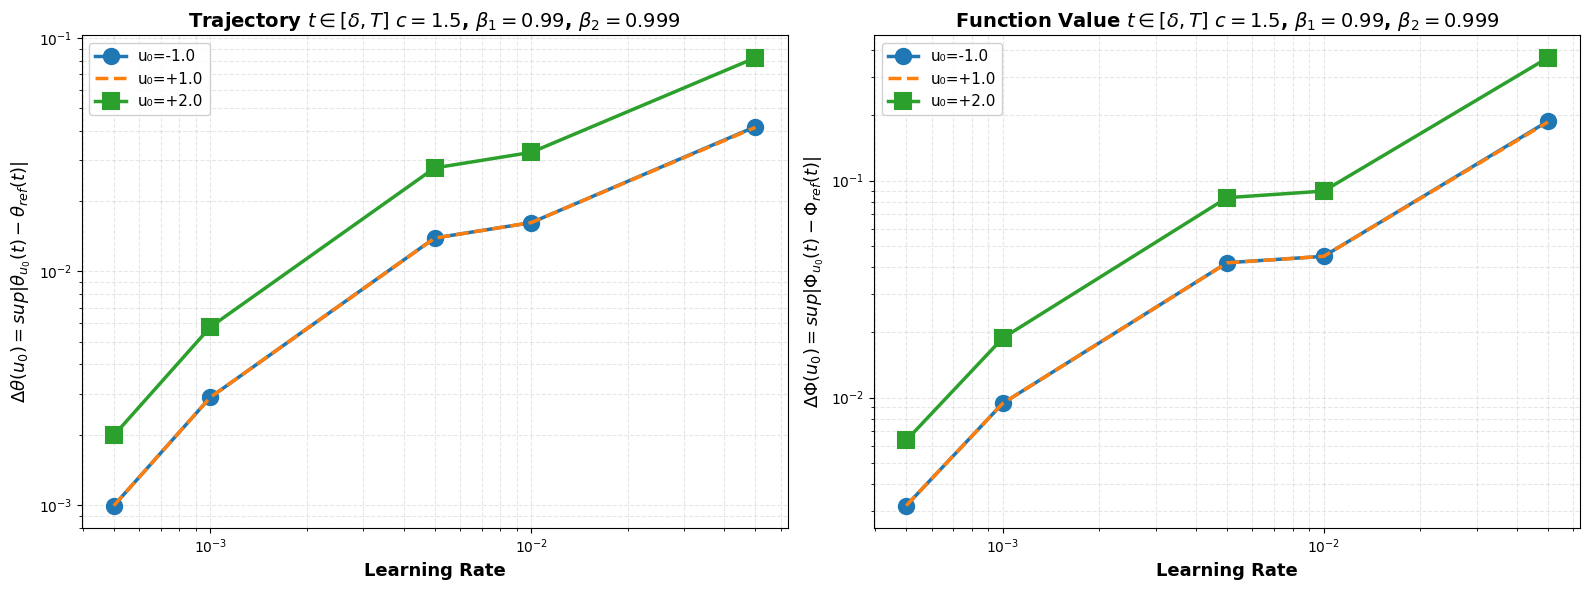


ANALYSIS COMPLETE


In [7]:
# ============================================================================
# PLOTTING: INDEPENDENCE METRICS vs LEARNING RATE
# ============================================================================

print("\n" + "="*70)
print("GENERATING PLOTS")
print("="*70)

if not df_independence.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Group by v0
    unique_v0s = sorted(df_independence['v0'].unique())
    print(f"Unique velocities to plot: {unique_v0s}")
    
    # Define colors and markers for each velocity
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    markers = ['o', 'D', 's']  # Circle for v0=-1.0, Diamond for v0=+1.0, Cross for v0=+2.0
    
    for i, v0 in enumerate(unique_v0s):
        df_v0 = df_independence[df_independence['v0'] == v0]
        print(f"  Plotting u0={v0:+.1f} with {len(df_v0)} points")
        
        
        # No marker for v0=+1.0
        if v0 == 1.0:
            ax1.loglog(df_v0['lr'], df_v0['Delta_theta'], 
                       linestyle='--', label=f'u₀={v0:+.1f}', 
                       color=colors[i], linewidth=2.5)
            
            ax2.loglog(df_v0['lr'], df_v0['Delta_Phi'], 
                       linestyle='--', label=f'u₀={v0:+.1f}', 
                       color=colors[i], linewidth=2.5)
        else:
            # For v0=-1.0 and v0=+2.0, use markers
            ax1.loglog(df_v0['lr'], df_v0['Delta_theta'], 
                       marker=markers[i], label=f'u₀={v0:+.1f}', 
                       color=colors[i], linewidth=2.5, markersize=11, 
                       markeredgewidth=1.5)
            
            ax2.loglog(df_v0['lr'], df_v0['Delta_Phi'], 
                       marker=markers[i], label=f'u₀={v0:+.1f}', 
                       color=colors[i], linewidth=2.5, markersize=11,
                       markeredgewidth=1.5)
    
    # Styling
    ax1.set_xlabel('Learning Rate', fontsize=13, fontweight='bold')
    ax1.set_ylabel(fr'$\Delta \theta(u_0) = sup|\theta_{{u_0}}(t) - \theta_{{ref}}(t)|$', fontsize=13, fontweight='bold')
    ax1.set_title(fr'Trajectory $t\in[\delta,T]$ $c={C_VALUE}$, $\beta_1={TARGET_BETA1}$, $\beta_2={TARGET_BETA2}$', 
                  fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11, loc='best', framealpha=0.9)
    ax1.grid(True, alpha=0.3, which='both', linestyle='--')
    
    ax2.set_xlabel('Learning Rate', fontsize=13, fontweight='bold')
    ax2.set_ylabel(fr'$\Delta \Phi(u_0) = sup|\Phi_{{u_0}}(t) - \Phi_{{ref}}(t)|$', fontsize=13, fontweight='bold')
    ax2.set_title(fr'Function Value $t\in[\delta,T]$ $c={C_VALUE}$, $\beta_1={TARGET_BETA1}$, $\beta_2={TARGET_BETA2}$', 
                  fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11, loc='best', framealpha=0.9)
    ax2.grid(True, alpha=0.3, which='both', linestyle='--')
    
    plt.tight_layout()
    
    output_fig = PLOTS_DIR / f'velocity_independence_vs_lr_c_{C_VALUE}_beta1_{TARGET_BETA1}_beta2_{TARGET_BETA2}.png'
    plt.savefig(output_fig, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: {output_fig}")
    plt.show()

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)